<a href="https://colab.research.google.com/github/Samihajmghrby/code-with-samiha/blob/main/finalprojectNLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================================
# PART 1 — ENVIRONMENT SETUP & DATASET UPLOAD
# ============================================================================
# What this cell does:
#   - Installs pinned, Colab-compatible package versions
#   - Imports everything used throughout the project
#   - Sets random seeds for reproducibility
#   - Detects GPU (T4 recommended) and falls back to CPU gracefully
#   - Provides a file picker to upload the Excel dataset
#   - Loads the dataset and runs basic sanity checks
#
# Run order: Part 1 -> Part 2 -> ... -> Part 8, sequentially.
# Enable GPU first: Runtime > Change runtime type > T4 GPU
# ============================================================================

# --- Cell 1.1: install dependencies (quiet, pinned for Colab stability) ---
# Pinning major versions avoids API breakage between transformers 4.x and 5.x.
!pip install -q "transformers>=4.40,<5" "accelerate>=0.30" "scikit-learn>=1.3" "gradio>=4.0" openpyxl wordcloud nltk matplotlib seaborn

# --- Cell 1.2: imports ---
import os, re, gc, random, warnings, time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             classification_report, confusion_matrix, roc_curve, roc_auc_score)
from scipy.sparse import hstack, csr_matrix

# PyTorch / HuggingFace
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer)

# --- Cell 1.3: NLTK data with safe download ---
import nltk
def _safe_nltk(pkgs):
    for p in pkgs:
        try: nltk.download(p, quiet=True)
        except Exception as e: print(f"  (could not fetch NLTK '{p}' — fallback will be used)")
_safe_nltk(['punkt','punkt_tab','stopwords','wordnet','omw-1.4',
            'averaged_perceptron_tagger','averaged_perceptron_tagger_eng'])
print("NLTK ready (with regex fallbacks in place if any download failed).")

# --- Cell 1.4: reproducibility ---
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

# --- Cell 1.5: device check + memory cleanup helper ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU: {gpu_name} ({gpu_mem:.1f} GB)")
    if 'T4' not in gpu_name and 'A100' not in gpu_name and 'V100' not in gpu_name:
        print("  (note: a non-T4 GPU is fine, just confirm runtime type)")
else:
    print("No GPU — code will still run on CPU, just slower (~4-6 min for fine-tuning).")

def cleanup_memory():
    """Free GPU and Python memory between heavy stages."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
cleanup_memory()
print("Setup complete.")

# --- Cell 1.6: upload the Excel dataset ---
# A file picker will appear. Choose: social_engineering_dataset.xlsx
from google.colab import files
uploaded = files.upload()
assert uploaded, "No file uploaded. Re-run this cell and select the .xlsx file."
EXCEL_FILE = list(uploaded.keys())[0]
print(f"Uploaded: {EXCEL_FILE}")

# --- Cell 1.7: load + sanity check ---
ATTACK_TYPES = ["phishing","impersonation","urgency","credential_theft","scam","emotional_manipulation"]
df_raw = pd.read_excel(EXCEL_FILE, sheet_name="dataset")

# Sanity checks
required_cols = ["text","label","attack_types"] + [f"is_{t}" for t in ATTACK_TYPES]
missing = [c for c in required_cols if c not in df_raw.columns]
assert not missing, f"Excel is missing columns: {missing}"
assert set(df_raw['label'].unique()) <= {"attack","safe"}, f"Unexpected labels: {df_raw['label'].unique()}"
df_raw = df_raw.dropna(subset=['text']).reset_index(drop=True)
df_raw['attack_types'] = df_raw['attack_types'].fillna('').apply(
    lambda x: [t for t in str(x).split(';') if t])

print(f"Loaded {len(df_raw)} rows")
print(f"Class balance:\n{df_raw['label'].value_counts()}")
print(f"\nAttack type counts:")
for at in ATTACK_TYPES:
    print(f"  {at:25s}: {df_raw[f'is_{at}'].sum()}")
df_raw.head()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 18.9 MB/s eta 0:00:00


NLTK ready (with regex fallbacks in place if any download failed).
No GPU — code will still run on CPU, just slower (~4-6 min for fine-tuning).
Setup complete.


Saving social_engineering_dataset.xlsx to social_engineering_dataset.xlsx
Uploaded: social_engineering_dataset.xlsx
Loaded 1016 rows
Class balance:
label
attack    508
safe      508
Name: count, dtype: int64

Attack type counts:
  phishing                 : 248
  impersonation            : 138
  urgency                  : 234
  credential_theft         : 214
  scam                     : 214
  emotional_manipulation   : 60


,text,label,attack_types,is_phishing,is_impersonation,is_urgency,is_credential_theft,is_scam,is_emotional_manipulation
0,Quick question: can you reset my sign-in detai...,attack,"[impersonation, credential_theft]",0,1,0,1,0,0
1,Heads up: company-wide password reset is comin...,safe,[],0,0,0,0,0,0
2,Your Notion subscription renewed successfully....,safe,[],0,0,0,0,0,0
3,Congratulations! You've won $499 in our intern...,attack,"[scam, credential_theft]",0,0,0,1,1,0
4,A login attempt from an unrecognized location ...,attack,"[phishing, credential_theft]",1,0,0,1,0,0


Cleaning examples:
  raw:   Quick question: can you reset my sign-in details? Help desk is slammed and I hav
  clean: quick question can you reset my sign in details help desk is slammed and i have 

  raw:   Heads up: company-wide password reset is coming Wednesday. IT will send the offi
  clean: heads up company wide password reset is coming wednesday it will send the offici

Tokens per message by class:
        mean  min  max
label                 
attack  18.3   11   29
safe    14.7    9   22

Top content words per class:
  [attack] account(114), could(94), need(76), login(72), sign(67), confirm(59), details(56), new(54), access(50), please(48), send(47), share(47)
  [safe] next(115), monday(82), friday(80), week(66), team(63), pm(57), tomorrow(54), calendar(49), invite(49), wednesday(43), reminder(40), session(39)

POS profile by class:
      attack   safe
ADJ    0.104  0.115
NOUN   0.408  0.448
PRON   0.176  0.091
VERB   0.264  0.293
ADV    0.048  0.052

NER examples (attack mess

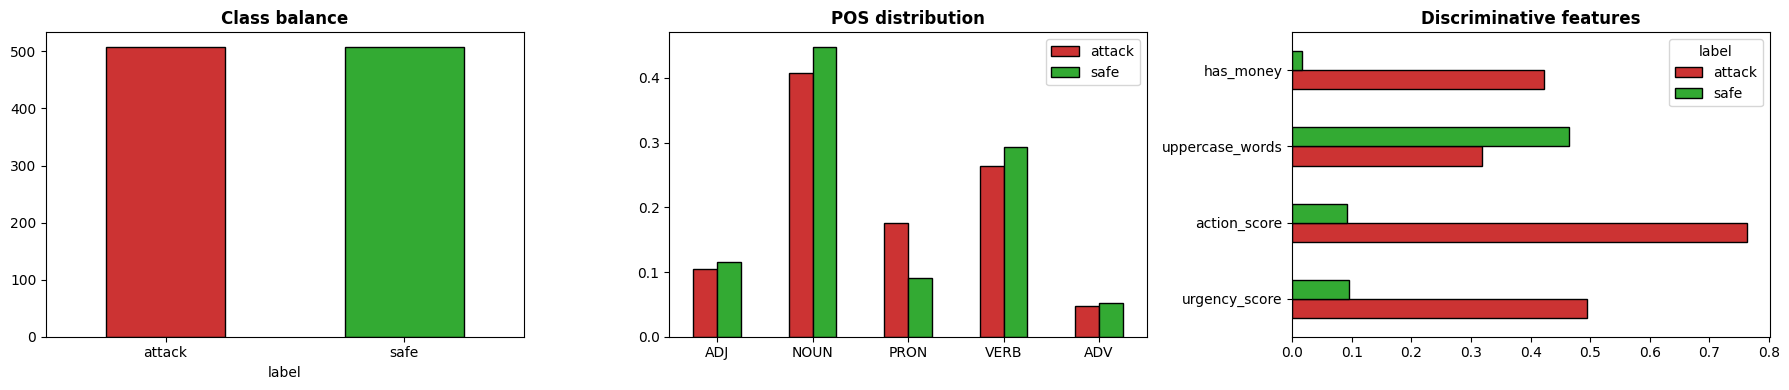

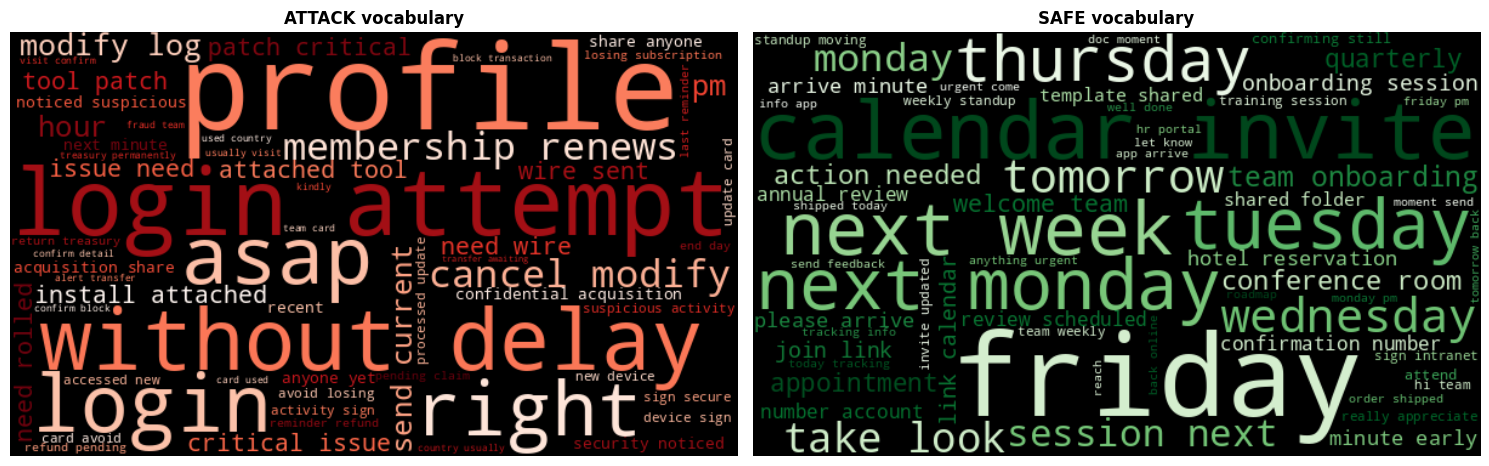


Label mapping: {'attack': 0, 'safe': 1}
Train: 812 | Test: 204
Preprocessing & NLP analysis complete.


In [2]:
# ============================================================================
# PART 2 — DATASET PREPROCESSING & NLP ANALYSIS
# ============================================================================
# Heavy NLP work happens here:
#   - Text normalization (URLs, emails, money, card numbers -> tokens)
#   - Robust tokenization with regex fallback if NLTK punkt missing
#   - Stopword removal, lemmatization
#   - Vocabulary analysis: which words separate attack from safe
#   - Per-class POS distribution
#   - Rule-based NER for entities common in attacks (brands, money, time)
#   - Linguistic feature engineering (urgency score, action score, etc.)
#   - Word clouds for visual vocabulary comparison
#
# These NLP outputs feed into Part 3 (classical ML) and stay available for
# the explainability section.
# ============================================================================

# --- Cell 2.1: robust tokenizer / pos / stemming helpers ---
# All NLTK calls are wrapped — if NLTK data didn't download, we fall back
# to regex so the project still runs end-to-end.

def safe_tokenize(text):
    """Word tokenizer with NLTK -> regex fallback."""
    try:
        from nltk.tokenize import word_tokenize
        return word_tokenize(str(text))
    except Exception:
        return re.findall(r"\b\w+\b", str(text))

def safe_pos(tokens):
    """POS tagger with fallback to all-NN."""
    try:
        from nltk import pos_tag
        return pos_tag(tokens)
    except Exception:
        return [(t, 'NN') for t in tokens]

try:
    from nltk.corpus import stopwords
    STOP = set(stopwords.words('english'))
except Exception:
    STOP = set("a an the and or but is are was were be been being to of in on for with at by from "
               "you your this that it we our i me my mine they them their have has had do does did "
               "will would could should can may might not no yes if then so as".split())

try:
    from nltk.stem import WordNetLemmatizer, PorterStemmer
    _lem = WordNetLemmatizer(); _stem = PorterStemmer()
    def lemmatize(w):
        try: return _lem.lemmatize(w)
        except Exception: return w
    def stem(w):
        try: return _stem.stem(w)
        except Exception: return w
except Exception:
    def lemmatize(w): return w
    def stem(w): return w

# --- Cell 2.2: text cleaning + entity normalization ---
def preprocess_text(text):
    """
    Normalize text by replacing entities with stable tokens. This helps the
    model learn 'a URL appears here' rather than memorizing specific links.
    """
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', ' urltoken ', text)        # URLs
    text = re.sub(r'\S+@\S+', ' emailtoken ', text)                    # emails
    text = re.sub(r'\b\d{4}[-\s]?\d{4}[-\s]?\d{4}[-\s]?\d{4}\b', ' cardtoken ', text)  # cards
    text = re.sub(r'\$[\d,]+\.?\d*', ' moneytoken ', text)             # money
    text = re.sub(r'#\d+', ' ordertoken ', text)                       # order numbers
    text = re.sub(r'[^\w\s]', ' ', text)                               # punctuation
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df = df_raw.copy()
df['clean_text'] = df['text'].apply(preprocess_text)
print("Cleaning examples:")
for i in range(2):
    print(f"  raw:   {df.iloc[i]['text'][:80]}")
    print(f"  clean: {df.iloc[i]['clean_text'][:80]}\n")

# --- Cell 2.3: tokenize & remove stopwords for analysis ---
df['tokens'] = df['text'].apply(lambda t: [w.lower() for w in safe_tokenize(t) if w.isalpha()])
df['content'] = df['tokens'].apply(lambda lst: [w for w in lst if w not in STOP])
df['lemmatized'] = df['content'].apply(lambda lst: ' '.join(lemmatize(w) for w in lst))
df['token_count'] = df['tokens'].apply(len)
print("Tokens per message by class:")
print(df.groupby('label')['token_count'].agg(['mean','min','max']).round(1))

# --- Cell 2.4: vocabulary contrast ---
print("\nTop content words per class:")
for label in ['attack','safe']:
    words = [w for lst in df[df['label']==label]['content'] for w in lst]
    top = Counter(words).most_common(12)
    print(f"  [{label}] " + ", ".join(f"{w}({c})" for w, c in top))

# --- Cell 2.5: POS distribution per class ---
def pos_profile(token_lists, sample=200):
    """Coarse POS profile, sampled for speed on large corpora."""
    c = Counter()
    for toks in token_lists[:sample]:
        for _, tag in safe_pos(toks):
            if tag.startswith('VB'): c['VERB'] += 1
            elif tag.startswith('NN'): c['NOUN'] += 1
            elif tag.startswith('JJ'): c['ADJ']  += 1
            elif tag.startswith('RB'): c['ADV']  += 1
            elif tag.startswith('PRP'): c['PRON']+= 1
    total = sum(c.values()) or 1
    return {k: v/total for k, v in c.items()}

attack_tok_lists = df[df['label']=='attack']['tokens'].tolist()
safe_tok_lists   = df[df['label']=='safe']['tokens'].tolist()
attack_pos = pos_profile(attack_tok_lists)
safe_pos_  = pos_profile(safe_tok_lists)
pos_df = pd.DataFrame({'attack': attack_pos, 'safe': safe_pos_}).fillna(0).round(3)
print("\nPOS profile by class:"); print(pos_df)

# --- Cell 2.6: rule-based NER for domain entities ---
# Reliable, fast, no external model download. Captures the entity types
# that matter for social engineering: brands, money, deadlines, links.
BRAND_LIST = ['paypal','amazon','netflix','spotify','microsoft','apple','google','dropbox',
              'linkedin','instagram','facebook','zoom','slack','adobe','github','notion','figma',
              'chase','citi','barclays','dhl','fedex','ups','usps','irs','hmrc']
TIME_PHRASES = ['within','today','immediately','now','asap','24 hours','30 minutes','this hour',
                'end of day','before','expires','deadline','right now']
def extract_entities(text):
    low = text.lower()
    ents = {'ORG':[], 'MONEY':[], 'TIME':[], 'LINK':[]}
    for b in BRAND_LIST:
        if b in low: ents['ORG'].append(b)
    ents['MONEY'] = re.findall(r'\$[\d,]+\.?\d*', text)
    for p in TIME_PHRASES:
        if p in low: ents['TIME'].append(p)
    if re.search(r'https?://|www\.|click here|link below|tap the link', low):
        ents['LINK'].append('link-cue')
    return {k: v for k, v in ents.items() if v}

print("\nNER examples (attack messages):")
for t in df[df['label']=='attack']['text'].head(4):
    print(f"  {t[:75]} -> {extract_entities(t)}")

# --- Cell 2.7: linguistic feature engineering ---
URGENCY_LEX = {'urgent','immediately','now','asap','expire','expires','today','hurry',
               'final','warning','alert','critical','limited','quickly','deadline','verify'}
ACTION_LEX  = {'click','verify','confirm','update','login','log','send','reply','call',
               'download','enter','transfer','wire','reset','provide','share','approve'}

def engineer_features(text):
    toks = [w.lower() for w in safe_tokenize(text)]
    return {
        'char_len': len(text),
        'word_len': len(toks),
        'exclaim': text.count('!'),
        'question': text.count('?'),
        'uppercase_words': sum(1 for w in text.split() if w.isupper() and len(w) > 1),
        'urgency_score': sum(1 for w in toks if w in URGENCY_LEX),
        'action_score': sum(1 for w in toks if w in ACTION_LEX),
        'has_money': 1 if re.search(r'\$[\d,]+', text) else 0,
        'has_link_cue': 1 if re.search(r'click|link|http|www|verify', text.lower()) else 0,
        'org_mentions': sum(1 for b in BRAND_LIST if b in text.lower()),
    }

eng = df['text'].apply(engineer_features).apply(pd.Series)
ENG_COLS = list(eng.columns)
df = pd.concat([df, eng], axis=1)
print("\nAverage engineered features by class:")
print(df.groupby('label')[ENG_COLS].mean().round(2).T)

# --- Cell 2.8: visualizations ---
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
df['label'].value_counts().plot(kind='bar', ax=axes[0],
    color=['#cc3333','#33aa33'], edgecolor='black')
axes[0].set_title('Class balance', fontweight='bold'); axes[0].tick_params(axis='x', rotation=0)
pos_df.plot(kind='bar', ax=axes[1], color=['#cc3333','#33aa33'], edgecolor='black')
axes[1].set_title('POS distribution', fontweight='bold'); axes[1].tick_params(axis='x', rotation=0)
df.groupby('label')[['urgency_score','action_score','uppercase_words','has_money']].mean().T.plot(
    kind='barh', ax=axes[2], color=['#cc3333','#33aa33'], edgecolor='black')
axes[2].set_title('Discriminative features', fontweight='bold')
plt.tight_layout(); plt.show()

# Word clouds
from wordcloud import WordCloud
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, (label, cmap) in zip(axes, [('attack','Reds'), ('safe','Greens')]):
    blob = ' '.join(df[df['label']==label]['lemmatized'])
    wc = WordCloud(width=600, height=350, background_color='black', colormap=cmap, max_words=60).generate(blob)
    ax.imshow(wc, interpolation='bilinear'); ax.axis('off')
    ax.set_title(f'{label.upper()} vocabulary', fontweight='bold')
plt.tight_layout(); plt.show()

# --- Cell 2.9: train/test split ---
label_encoder = LabelEncoder()
df['label_encoded'] = label_encoder.fit_transform(df['label'])  # attack=0, safe=1
print(f"\nLabel mapping: {dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))}")

X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['label_encoded'],
    test_size=0.2, random_state=SEED, stratify=df['label_encoded'])
train_idx, test_idx = X_train.index, X_test.index
print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print("Preprocessing & NLP analysis complete.")

TF-IDF matrix: (812, 2026)  (2026 features)
Sample bigrams: ['10 30', '10 am', '10 minutes', '10 pm', '11 am', '11 pm', '24 hours', '30 am']
Combined: (812, 2036)  (2026 tfidf + 10 engineered)

Training classical models (this is fast):
  LogisticRegression (TF-IDF)           acc=0.995  f1=0.995  (0.1s)
  LinearSVM (TF-IDF)                    acc=0.995  f1=0.995  (0.0s)
  RandomForest (TF-IDF)                 acc=0.990  f1=0.990  (0.9s)
  LogisticRegression (TF-IDF+NLP)       acc=0.995  f1=0.995  (0.0s)
  LinearSVM (TF-IDF+NLP)                acc=0.995  f1=0.995  (0.0s)
  RandomForest (TF-IDF+NLP)             acc=0.995  f1=0.995  (0.9s)

Best classical: LogisticRegression (TF-IDF)  F1=0.995
              precision    recall  f1-score   support

      attack       0.99      1.00      1.00       102
        safe       1.00      0.99      1.00       102

    accuracy                           1.00       204
   macro avg       1.00      1.00      1.00       204
weighted avg       1.00      

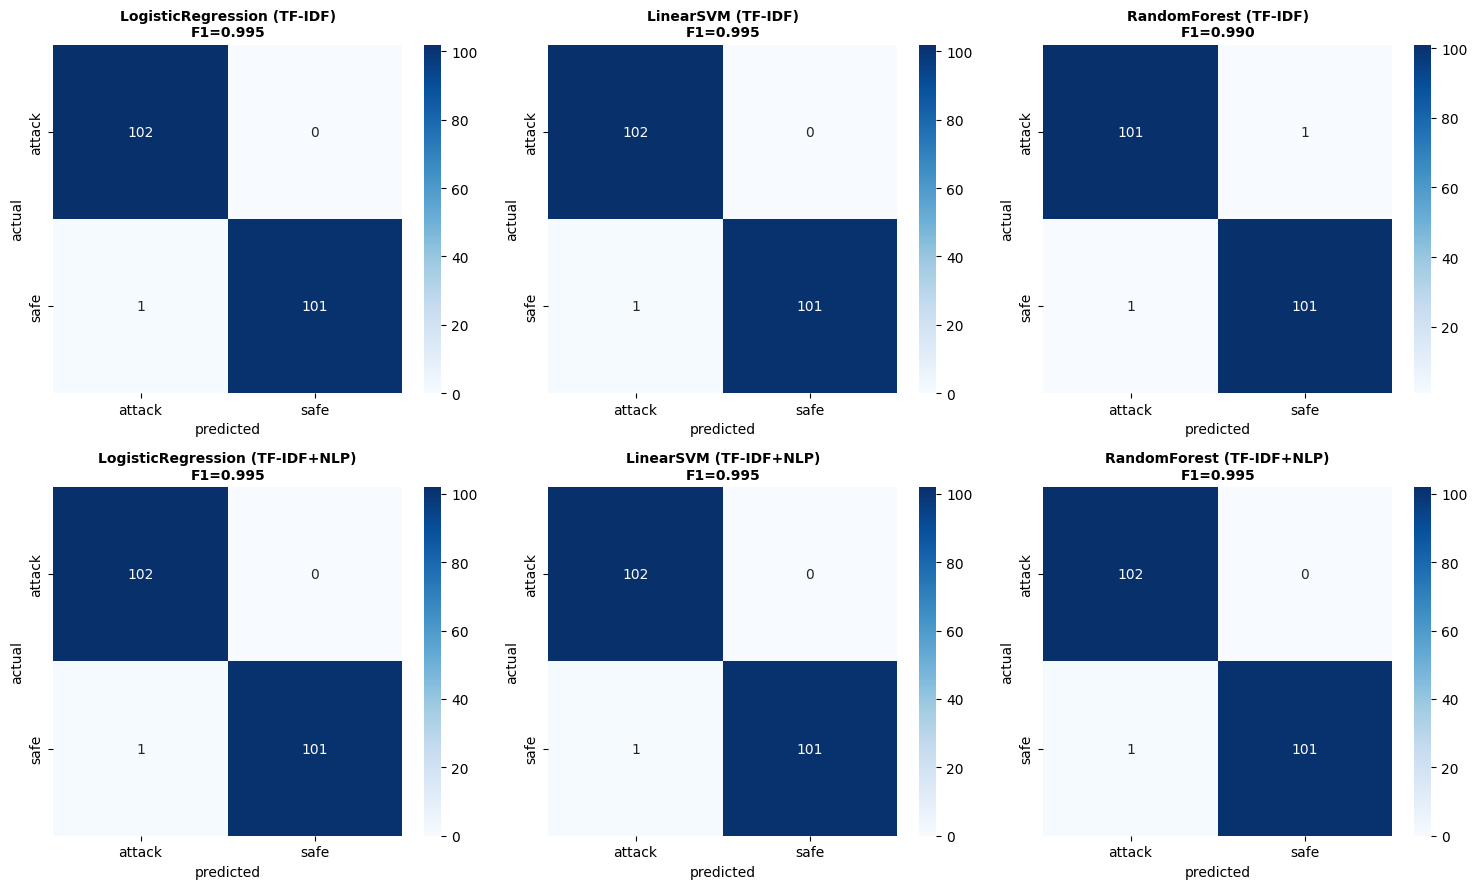

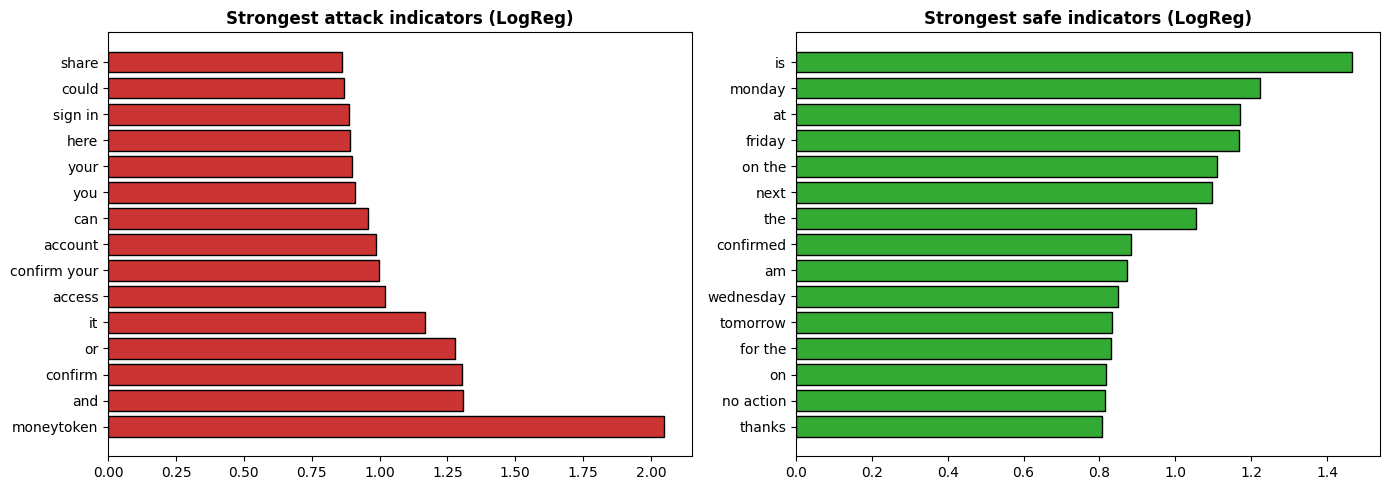

Classical baselines complete.


In [3]:
# ============================================================================
# PART 3 — CLASSICAL NLP + ML BASELINES
# ============================================================================
# Three classical models on two feature sets, six total comparisons:
#   - Logistic Regression, Linear SVM, Random Forest
#   - Features: TF-IDF (1-2 grams) | TF-IDF + engineered linguistic features
# Plus 5-fold cross-validation and feature-importance analysis.
# These baselines are what the fine-tuned transformer will be compared to.
# ============================================================================

# --- Cell 3.1: TF-IDF feature extraction ---
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=2, sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)
feature_names = tfidf.get_feature_names_out()
print(f"TF-IDF matrix: {X_train_tfidf.shape}  ({len(feature_names)} features)")
print(f"Sample bigrams: {[f for f in feature_names if ' ' in f][:8]}")

# --- Cell 3.2: combine with engineered features (scaled) ---
scaler = MinMaxScaler()
eng_train = scaler.fit_transform(df.loc[train_idx, ENG_COLS].values)
eng_test  = scaler.transform(df.loc[test_idx, ENG_COLS].values)
X_train_combined = hstack([X_train_tfidf, csr_matrix(eng_train)])
X_test_combined  = hstack([X_test_tfidf,  csr_matrix(eng_test)])
print(f"Combined: {X_train_combined.shape}  ({X_train_tfidf.shape[1]} tfidf + {eng_train.shape[1]} engineered)")

# --- Cell 3.3: train all 6 combinations ---
def fresh_models():
    return {
        'LogisticRegression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED),
        'LinearSVM':          LinearSVC(max_iter=2000, class_weight='balanced', random_state=SEED),
        'RandomForest':       RandomForestClassifier(n_estimators=150, max_depth=20,
                                                     class_weight='balanced', random_state=SEED, n_jobs=-1),
    }

classical_results = {}
print("\nTraining classical models (this is fast):")
for feat_name, Xtr, Xte in [('TF-IDF', X_train_tfidf, X_test_tfidf),
                            ('TF-IDF+NLP', X_train_combined, X_test_combined)]:
    for mname, model in fresh_models().items():
        key = f"{mname} ({feat_name})"
        t0 = time.time()
        model.fit(Xtr, y_train)
        pred = model.predict(Xte)
        elapsed = time.time() - t0
        classical_results[key] = {
            'model': model, 'predictions': pred,
            'accuracy':  accuracy_score(y_test, pred),
            'f1':        f1_score(y_test, pred, average='weighted'),
            'precision': precision_score(y_test, pred, average='weighted'),
            'recall':    recall_score(y_test, pred, average='weighted'),
            'train_time': elapsed,
        }
        r = classical_results[key]
        print(f"  {key:36s}  acc={r['accuracy']:.3f}  f1={r['f1']:.3f}  ({elapsed:.1f}s)")

# Keep clean handles to TF-IDF-only models (used by later parts)
classical_results_primary = {
    'Logistic Regression': classical_results['LogisticRegression (TF-IDF)'],
    'Linear SVM':          classical_results['LinearSVM (TF-IDF)'],
    'Random Forest':       classical_results['RandomForest (TF-IDF)'],
}

best_key = max(classical_results, key=lambda k: classical_results[k]['f1'])
print(f"\nBest classical: {best_key}  F1={classical_results[best_key]['f1']:.3f}")
print(classification_report(y_test, classical_results[best_key]['predictions'],
                            target_names=label_encoder.classes_))

# --- Cell 3.4: 5-fold cross-validation ---
print("5-fold cross-validation (F1 weighted):")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
X_all = tfidf.transform(df['clean_text']); y_all = df['label_encoded']
for mname, model in fresh_models().items():
    s = cross_val_score(model, X_all, y_all, cv=cv, scoring='f1_weighted', n_jobs=-1)
    print(f"  {mname:20s}: {s.mean():.3f} (+/- {s.std():.3f})")

# --- Cell 3.5: confusion matrices ---
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (key, r) in zip(axes.flatten(), classical_results.items()):
    sns.heatmap(confusion_matrix(y_test, r['predictions']), annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, ax=ax)
    ax.set_title(f"{key}\nF1={r['f1']:.3f}", fontweight='bold', fontsize=10)
    ax.set_xlabel('predicted'); ax.set_ylabel('actual')
plt.tight_layout(); plt.show()

# --- Cell 3.6: most predictive words (LogReg, TF-IDF only) ---
lr = classical_results_primary['Logistic Regression']['model']
coef = lr.coef_[0]   # attack=0 -> negative coef pushes toward attack
top_attack_idx = np.argsort(coef)[:15]
top_safe_idx   = np.argsort(coef)[-15:]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh([feature_names[i] for i in top_attack_idx], [abs(coef[i]) for i in top_attack_idx],
             color='#cc3333', edgecolor='black')
axes[0].set_title('Strongest attack indicators (LogReg)', fontweight='bold')
axes[1].barh([feature_names[i] for i in top_safe_idx], [coef[i] for i in top_safe_idx],
             color='#33aa33', edgecolor='black')
axes[1].set_title('Strongest safe indicators (LogReg)', fontweight='bold')
plt.tight_layout(); plt.show()

cleanup_memory()
print("Classical baselines complete.")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenized: train 812 | test 204 | max_len 64


...

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded. Trainable params: 14,767,874 / 66,955,010  (22.1%)
Starting fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.387700,0.207260,0.936275,0.936273,0.936316,0.936275
2,0.144700,0.068128,0.985294,0.985291,0.985714,0.985294
3,0.056400,0.047420,0.990196,0.990195,0.990385,0.990196



Done. Training took 610 seconds.



Fine-tuned DistilBERT — test set:
              precision    recall  f1-score   support

      attack       0.98      1.00      0.99       102
        safe       1.00      0.98      0.99       102

    accuracy                           0.99       204
   macro avg       0.99      0.99      0.99       204
weighted avg       0.99      0.99      0.99       204



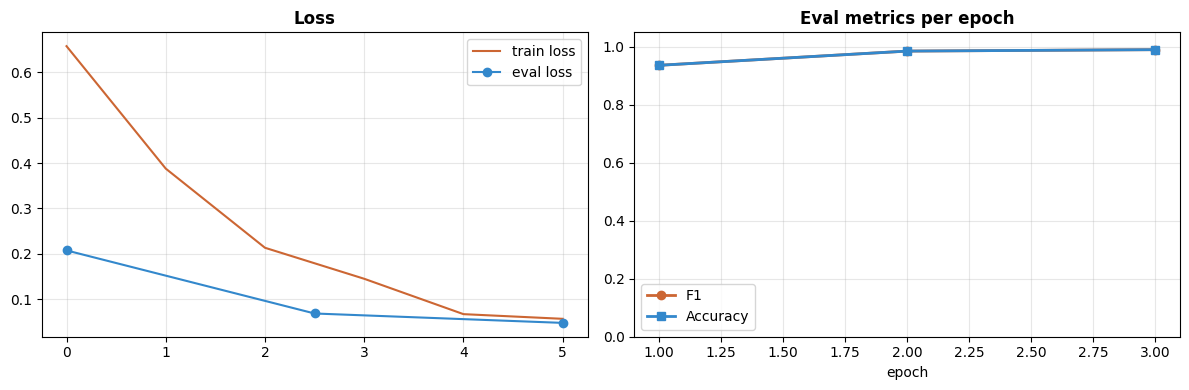

Model saved to: ./fine_tuned_se_binary
  [ATTACK 96%] URGENT: verify your bank account immediately or it will be locked.
  [SAFE 98%] Hey, are we still on for coffee tomorrow morning?
Binary fine-tuning complete.


In [4]:
# ============================================================================
# PART 4 — DISTILBERT FINE-TUNING (BINARY: attack vs safe)
# ============================================================================
# Local fine-tuning, no API. Optimized for T4 GPU and Colab stability:
#   - 64-token max sequences (most messages fit easily)
#   - 3 epochs is plenty for ~800 training samples
#   - Frozen embeddings + bottom 4 of 6 transformer layers
#   - FP16 mixed precision when GPU is available
#   - load_best_model_at_end with eval-each-epoch
# Expected runtime: ~60-90 seconds on T4, ~3-4 min on CPU.
# ============================================================================

MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 64

# --- Cell 4.1: API-compatibility helper ---
# transformers 4.x used `evaluation_strategy`, 5.x renamed to `eval_strategy`.
# This function works with either.
def make_training_args(**kw):
    try:
        return TrainingArguments(eval_strategy="epoch", save_strategy="epoch", **kw)
    except TypeError:
        return TrainingArguments(evaluation_strategy="epoch", save_strategy="epoch", **kw)

# --- Cell 4.2: tokenize ---
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def encode(texts, labels):
    enc = tokenizer(list(texts), truncation=True, padding='max_length',
                    max_length=MAX_LEN, return_tensors='pt')
    return enc, torch.tensor(list(labels), dtype=torch.long)

train_enc, train_lbl = encode(X_train, y_train)
test_enc, test_lbl   = encode(X_test, y_test)

class SEDataset(Dataset):
    def __init__(self, enc, lbl): self.enc, self.lbl = enc, lbl
    def __len__(self): return len(self.lbl)
    def __getitem__(self, i):
        return {'input_ids':      self.enc['input_ids'][i],
                'attention_mask': self.enc['attention_mask'][i],
                'labels':         self.lbl[i]}

train_ds = SEDataset(train_enc, train_lbl)
test_ds  = SEDataset(test_enc,  test_lbl)
print(f"Tokenized: train {len(train_ds)} | test {len(test_ds)} | max_len {MAX_LEN}")

# --- Cell 4.3: load model & freeze lower layers ---
cleanup_memory()
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2,
    id2label={0:'attack', 1:'safe'},
    label2id={'attack':0, 'safe':1}).to(device)

# Freeze for speed and stability on small datasets
for p in model.distilbert.embeddings.parameters():
    p.requires_grad = False
for layer in model.distilbert.transformer.layer[:4]:
    for p in layer.parameters():
        p.requires_grad = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Model loaded. Trainable params: {trainable:,} / {total:,}  ({100*trainable/total:.1f}%)")

# --- Cell 4.4: metrics + trainer ---
def compute_metrics_binary(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy':  accuracy_score(labels, preds),
        'f1':        f1_score(labels, preds, average='weighted'),
        'precision': precision_score(labels, preds, average='weighted'),
        'recall':    recall_score(labels, preds, average='weighted'),
    }

args = make_training_args(
    output_dir='./se_binary',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=3e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_steps=25,
    seed=SEED,
    fp16=torch.cuda.is_available(),
    report_to="none",
    save_total_limit=1,
    dataloader_num_workers=0,    # safest in Colab
)

trainer = Trainer(
    model=model, args=args,
    train_dataset=train_ds, eval_dataset=test_ds,
    compute_metrics=compute_metrics_binary)

# --- Cell 4.5: TRAIN ---
print("Starting fine-tuning...")
t0 = time.time()
trainer.train()
train_time = time.time() - t0
print(f"\nDone. Training took {train_time:.0f} seconds.")

# --- Cell 4.6: evaluate ---
pred_out = trainer.predict(test_ds)
transformer_preds = np.argmax(pred_out.predictions, axis=-1)
transformer_probs = torch.softmax(torch.tensor(pred_out.predictions), dim=-1).numpy()

print("\nFine-tuned DistilBERT — test set:")
print(classification_report(y_test, transformer_preds, target_names=label_encoder.classes_))

# --- Cell 4.7: training-curve visualization ---
hist = trainer.state.log_history
f1s  = [h['eval_f1']       for h in hist if 'eval_f1' in h]
accs = [h['eval_accuracy'] for h in hist if 'eval_accuracy' in h]
losses_train = [h['loss']      for h in hist if 'loss' in h and 'eval_loss' not in h]
losses_eval  = [h['eval_loss'] for h in hist if 'eval_loss' in h]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
if losses_train:
    axes[0].plot(losses_train, color='#cc6633', label='train loss')
if losses_eval:
    epochs = list(range(1, len(losses_eval)+1))
    axes[0].plot(np.linspace(0, len(losses_train)-1, len(losses_eval)) if losses_train else epochs,
                 losses_eval, color='#3388cc', marker='o', label='eval loss')
axes[0].set_title('Loss', fontweight='bold'); axes[0].legend(); axes[0].grid(alpha=0.3)

if f1s:
    epochs = list(range(1, len(f1s)+1))
    axes[1].plot(epochs, f1s, marker='o', color='#cc6633', label='F1', linewidth=2)
    axes[1].plot(epochs, accs, marker='s', color='#3388cc', label='Accuracy', linewidth=2)
    axes[1].set_title('Eval metrics per epoch', fontweight='bold')
    axes[1].legend(); axes[1].grid(alpha=0.3); axes[1].set_xlabel('epoch'); axes[1].set_ylim(0, 1.05)
plt.tight_layout(); plt.show()

# --- Cell 4.8: save + inference helper ---
SAVE_DIR = './fine_tuned_se_binary'
model.save_pretrained(SAVE_DIR); tokenizer.save_pretrained(SAVE_DIR)
print(f"Model saved to: {SAVE_DIR}")

def predict_transformer(text):
    """Single-message inference using the fine-tuned binary model."""
    model.eval()
    inp = tokenizer(text, truncation=True, padding='max_length',
                    max_length=MAX_LEN, return_tensors='pt').to(device)
    with torch.no_grad():
        probs = torch.softmax(model(**inp).logits, dim=-1).cpu().numpy()[0]
    pred_idx = int(np.argmax(probs))
    return label_encoder.classes_[pred_idx], float(np.max(probs) * 100), probs

# Quick smoke test
for msg in ["URGENT: verify your bank account immediately or it will be locked.",
            "Hey, are we still on for coffee tomorrow morning?"]:
    lbl, conf, _ = predict_transformer(msg)
    print(f"  [{lbl.upper()} {conf:.0f}%] {msg}")

cleanup_memory()
print("Binary fine-tuning complete.")

Attack samples: 508 | labels: ['phishing', 'impersonation', 'urgency', 'credential_theft', 'scam', 'emotional_manipulation']
Multi-label split: train 381 | test 127


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training multi-label model...


Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro
1,0.537500,0.454892,0.760736,0.604490
2,0.307600,0.266811,0.937163,0.945114
3,0.202600,0.173445,0.982079,0.984155
4,0.142000,0.135297,0.983842,0.985838
5,0.143900,0.126265,0.985612,0.987555



Done. Took 458 seconds.


Final eval: {'eval_loss': 0.12626513838768005, 'eval_f1_micro': 0.9856115107913669, 'eval_f1_macro': 0.9875554274586573, 'eval_runtime': 13.0423, 'eval_samples_per_second': 9.738, 'eval_steps_per_second': 0.613, 'epoch': 5.0}

Per-label F1:
  phishing                   F1=0.992  (positive support: 61)
  impersonation              F1=0.987  (positive support: 38)
  urgency                    F1=0.984  (positive support: 61)
  credential_theft           F1=0.973  (positive support: 58)
  scam                       F1=0.989  (positive support: 48)
  emotional_manipulation     F1=1.000  (positive support: 13)


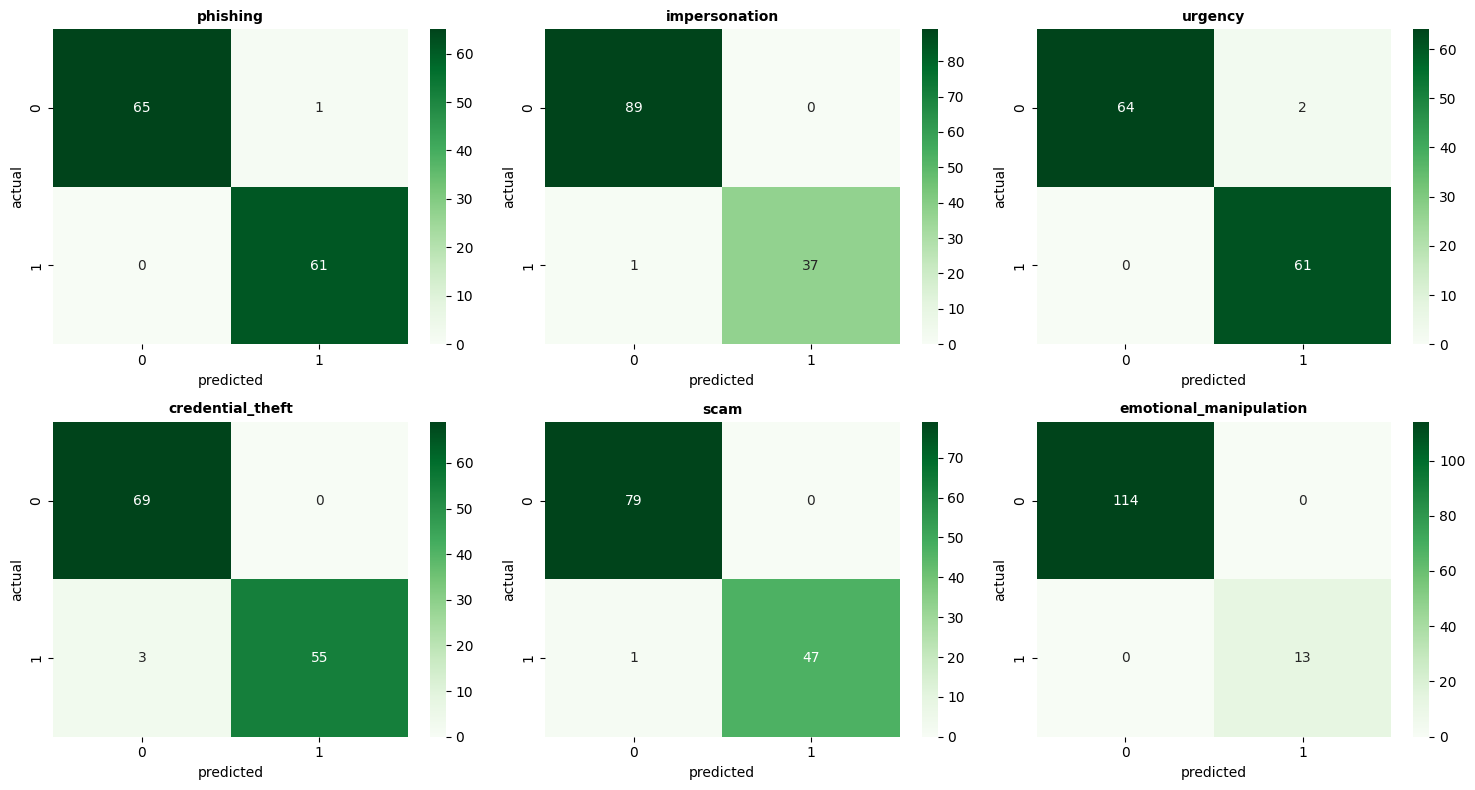


> CEO Request: wire $20,000 to this account immediately. Confidential.
  detected: []
    phishing                  0.49 █████████
    urgency                   0.48 █████████
    scam                      0.47 █████████
    impersonation             0.28 █████
    credential_theft          0.20 ████
    emotional_manipulation    0.02 

> You've won a free iPhone! Click here to claim your prize today.
  detected: ['phishing', 'credential_theft']
    credential_theft          0.72 ██████████████
    phishing                  0.64 ████████████
    scam                      0.28 █████
    impersonation             0.07 █
    emotional_manipulation    0.05 █
    urgency                   0.05 
Multi-label fine-tuning complete.


In [5]:
# ============================================================================
# PART 5 — MULTI-LABEL ATTACK TYPE CLASSIFICATION
# ============================================================================
# A second fine-tuned DistilBERT that predicts WHICH attack types are present:
#   phishing, impersonation, urgency, credential_theft, scam, emotional_manipulation
#
# Trained only on the attack subset (safe messages have no labels to predict).
# Uses BCE-with-logits loss for independent per-label predictions.
# Expected runtime: ~60-90 seconds on T4.
# ============================================================================

# --- Cell 5.1: build attack-only data ---
attack_df = df[df['label']=='attack'].reset_index(drop=True)
multi_cols = [f'is_{t}' for t in ATTACK_TYPES]
y_multi = attack_df[multi_cols].values.astype('float32')
print(f"Attack samples: {len(attack_df)} | labels: {ATTACK_TYPES}")

# --- Cell 5.2: tokenize + split ---
multi_enc = tokenizer(attack_df['clean_text'].tolist(), truncation=True,
                      padding='max_length', max_length=MAX_LEN, return_tensors='pt')

from sklearn.model_selection import train_test_split as tts
idx_tr, idx_te = tts(range(len(attack_df)), test_size=0.25, random_state=SEED)

class MultiDS(Dataset):
    def __init__(self, enc, idx, y):
        self.ids  = enc['input_ids'][idx]
        self.mask = enc['attention_mask'][idx]
        self.y    = torch.tensor(y[idx], dtype=torch.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self, i):
        return {'input_ids': self.ids[i], 'attention_mask': self.mask[i], 'labels': self.y[i]}

train_multi = MultiDS(multi_enc, idx_tr, y_multi)
test_multi  = MultiDS(multi_enc, idx_te, y_multi)
print(f"Multi-label split: train {len(train_multi)} | test {len(test_multi)}")

# --- Cell 5.3: load model + freeze + BCE trainer ---
cleanup_memory()
multi_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=len(ATTACK_TYPES),
    problem_type="multi_label_classification").to(device)

for p in multi_model.distilbert.embeddings.parameters():
    p.requires_grad = False
for layer in multi_model.distilbert.transformer.layer[:4]:
    for p in layer.parameters():
        p.requires_grad = False

class MultiTrainer(Trainer):
    """Trainer overriding compute_loss to use BCE for multi-label outputs."""
    def compute_loss(self, model, inputs, return_outputs=False, **kw):
        labels = inputs.pop("labels")
        out = model(**inputs)
        loss = nn.BCEWithLogitsLoss()(out.logits, labels)
        return (loss, out) if return_outputs else loss

def compute_metrics_multi(eval_pred):
    logits, labels = eval_pred
    preds = (torch.sigmoid(torch.tensor(logits)).numpy() > 0.5).astype(int)
    return {
        'f1_micro': f1_score(labels, preds, average='micro', zero_division=0),
        'f1_macro': f1_score(labels, preds, average='macro', zero_division=0),
    }

multi_args = make_training_args(
    output_dir='./se_multi',
    num_train_epochs=5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    learning_rate=4e-5,
    warmup_ratio=0.1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_micro",
    greater_is_better=True,
    logging_steps=10,
    seed=SEED,
    fp16=torch.cuda.is_available(),
    report_to="none",
    save_total_limit=1,
    dataloader_num_workers=0,
)

multi_trainer = MultiTrainer(
    model=multi_model, args=multi_args,
    train_dataset=train_multi, eval_dataset=test_multi,
    compute_metrics=compute_metrics_multi)

# --- Cell 5.4: TRAIN ---
print("Training multi-label model...")
t0 = time.time()
multi_trainer.train()
print(f"\nDone. Took {time.time()-t0:.0f} seconds.")
print("Final eval:", multi_trainer.evaluate())

# --- Cell 5.5: per-label evaluation ---
mp = multi_trainer.predict(test_multi)
multi_preds = (torch.sigmoid(torch.tensor(mp.predictions)).numpy() > 0.5).astype(int)
multi_true  = y_multi[idx_te]

print("\nPer-label F1:")
for i, name in enumerate(ATTACK_TYPES):
    f1 = f1_score(multi_true[:, i], multi_preds[:, i], zero_division=0)
    support = int(multi_true[:, i].sum())
    print(f"  {name:25s}  F1={f1:.3f}  (positive support: {support})")

# Per-label confusion matrices
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, name in enumerate(ATTACK_TYPES):
    cm = confusion_matrix(multi_true[:, i], multi_preds[:, i])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[i//3, i%3])
    axes[i//3, i%3].set_title(name, fontweight='bold', fontsize=10)
    axes[i//3, i%3].set_xlabel('predicted'); axes[i//3, i%3].set_ylabel('actual')
plt.tight_layout(); plt.show()

# --- Cell 5.6: save + inference helper ---
multi_model.save_pretrained('./fine_tuned_se_multi')
def predict_attack_types(text):
    """Predict which attack types are present in a given message."""
    multi_model.eval()
    inp = tokenizer(text, truncation=True, padding='max_length',
                    max_length=MAX_LEN, return_tensors='pt').to(device)
    with torch.no_grad():
        probs = torch.sigmoid(multi_model(**inp).logits).cpu().numpy()[0]
    return {n: float(probs[i]) for i, n in enumerate(ATTACK_TYPES)}, \
           [n for i, n in enumerate(ATTACK_TYPES) if probs[i] > 0.5]

# Quick test
for m in ["CEO Request: wire $20,000 to this account immediately. Confidential.",
          "You've won a free iPhone! Click here to claim your prize today."]:
    probs, det = predict_attack_types(m)
    print(f"\n> {m}\n  detected: {det}")
    for n, p in sorted(probs.items(), key=lambda x:-x[1]):
        print(f"    {n:25s} {p:.2f} {'█'*int(p*20)}")

cleanup_memory()
print("Multi-label fine-tuning complete.")

DistilBertSdpaAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


  THREAT ANALYSIS REPORT

input: URGENT: Your bank account has been locked. Verify your identity immediately.
-------------------------------------------------------

[1] BINARY VERDICT  (fine-tuned DistilBERT)
    -> ATTACK  (confidence 92.9%)
    p(attack)=0.929   p(safe)=0.071

[2] ATTACK TYPING  (multi-label)
    detected: phishing, credential_theft
    phishing                  0.77 █████████████  <- ACTIVE
    credential_theft          0.69 ████████████  <- ACTIVE
    scam                      0.46 ████████
    urgency                   0.29 █████
    emotional_manipulation    0.05 
    impersonation             0.03 

[3] SUSPICIOUS TOKENS  (attention)
    [HIGH] urgent             1.00 ██████████████████
    [HIGH] .                  0.95 █████████████████
    [HIGH] :                  0.95 █████████████████
    [HIGH] .                  0.94 ████████████████
    [MED ] your               0.66 ███████████
    [MED ] has                0.54 █████████
    [MED ] your             

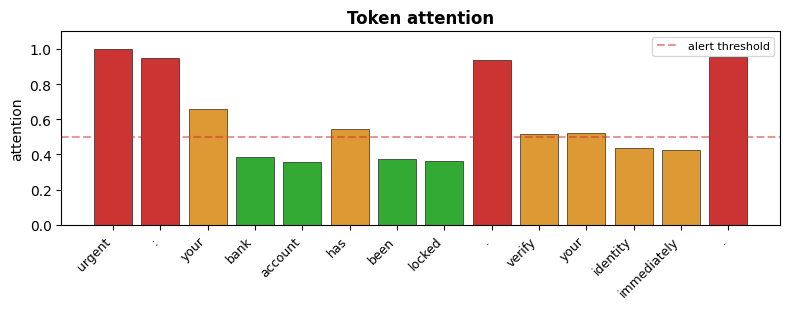

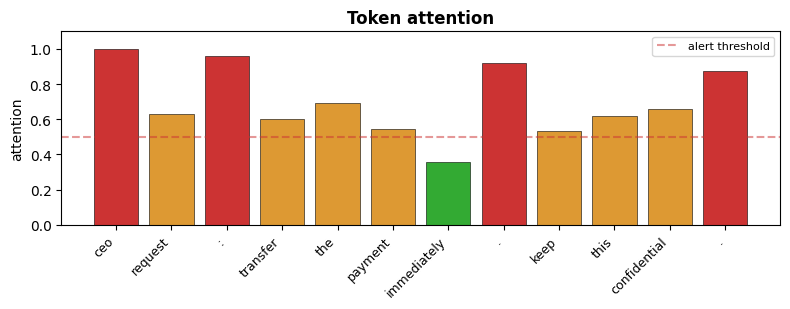

Explainability complete.


In [6]:
# ============================================================================
# PART 6 — EXPLAINABILITY
# ============================================================================
# Multiple views on WHY the model flagged a message:
#   - Attention weights from DistilBERT (which tokens drove the classification)
#   - Token importance via attention averaged across layers and heads
#   - Classical word contributions (TF-IDF * LR coefficients)
#   - Confidence scores
#   - Highlighted-text view: words flagged at HIGH/MED attention
# ============================================================================

# --- Cell 6.1: classical feature attribution ---
lr_model = classical_results_primary['Logistic Regression']['model']

def explain_classical(text, top_n=8):
    """
    Decompose a LogReg prediction into per-word contributions.
    Sign convention: positive = pushes toward 'attack' class.
    """
    vec = tfidf.transform([preprocess_text(text)])
    contribs = {}
    for idx in vec.nonzero()[1]:
        # attack = label 0, so a negative LR coefficient pushes toward attack.
        # We negate so positive contribution = attack signal (easier to read).
        contribs[feature_names[idx]] = -(vec[0, idx] * lr_model.coef_[0][idx])
    pred = label_encoder.classes_[lr_model.predict(vec)[0]]
    ranked = sorted(contribs.items(), key=lambda x: abs(x[1]), reverse=True)[:top_n]
    return pred, ranked

# --- Cell 6.2: attention extraction from DistilBERT ---
def get_attention(text):
    """
    Returns word-level attention scores (CLS->token), averaged over all
    transformer layers and heads. Subwords are merged back into whole words.
    """
    model.eval()
    inp = tokenizer(text, truncation=True, padding='max_length',
                    max_length=MAX_LEN, return_tensors='pt').to(device)
    with torch.no_grad():
        out = model(**inp, output_attentions=True)
    # Stack: (layers, batch, heads, seq_len, seq_len) -> avg over layers+heads
    attn = torch.stack(out.attentions).mean(dim=[0, 1, 2])[0].cpu().numpy()

    toks = tokenizer.convert_ids_to_tokens(inp['input_ids'][0])
    mask = inp['attention_mask'][0].cpu().numpy()

    words, scores = [], []
    for i, (tok, m) in enumerate(zip(toks, mask)):
        if m == 1 and tok not in ['[CLS]', '[SEP]', '[PAD]']:
            if tok.startswith('##') and words:
                words[-1] += tok[2:]
                scores[-1] = max(scores[-1], attn[i])
            else:
                words.append(tok); scores.append(attn[i])
    scores = np.array(scores)
    if scores.max() > 0:
        scores = scores / scores.max()    # normalize to [0,1]
    return words, scores

# --- Cell 6.3: highlight + plot ---
def highlight_text(text):
    """Return text with HIGH-attention words in brackets/uppercase."""
    words, scores = get_attention(text)
    parts = []
    for w, s in zip(words, scores):
        if   s > 0.7: parts.append(f"[{w.upper()}]")
        elif s > 0.4: parts.append(f"({w})")
        else:          parts.append(w)
    return ' '.join(parts)

def plot_attention(text):
    words, scores = get_attention(text)
    words, scores = words[:30], scores[:30]
    colors = ['#cc3333' if s > 0.7 else '#dd9933' if s > 0.4 else '#33aa33' for s in scores]
    plt.figure(figsize=(max(8, len(words) * 0.45), 3.2))
    plt.bar(range(len(words)), scores, color=colors, edgecolor='black', linewidth=0.4)
    plt.xticks(range(len(words)), words, rotation=45, ha='right', fontsize=9)
    plt.axhline(0.5, color='#cc3333', ls='--', alpha=0.5, label='alert threshold')
    plt.ylabel('attention'); plt.title('Token attention', fontweight='bold')
    plt.legend(fontsize=8); plt.ylim(0, 1.1); plt.tight_layout(); plt.show()

# --- Cell 6.4: combined explanation ---
def full_report(text):
    """
    Build a complete threat analysis report combining:
      - Binary verdict + confidence
      - Multi-label attack typing
      - Attention-based token highlights
      - Classical model keyword contributions
    """
    lines = ["="*55, "  THREAT ANALYSIS REPORT", "="*55, f"\ninput: {text}", "-"*55]

    # 1. Binary verdict
    lbl, conf, probs = predict_transformer(text)
    lines += [f"\n[1] BINARY VERDICT  (fine-tuned DistilBERT)",
              f"    -> {lbl.upper()}  (confidence {conf:.1f}%)",
              f"    p(attack)={probs[0]:.3f}   p(safe)={probs[1]:.3f}"]

    # 2. Multi-label (only if attack)
    if lbl == 'attack':
        ap, det = predict_attack_types(text)
        lines.append(f"\n[2] ATTACK TYPING  (multi-label)")
        lines.append(f"    detected: {', '.join(det) if det else 'no clear category'}")
        for n, p in sorted(ap.items(), key=lambda x:-x[1]):
            bar = '█' * int(p * 18)
            flag = '  <- ACTIVE' if p > 0.5 else ''
            lines.append(f"    {n:25s} {p:.2f} {bar}{flag}")

    # 3. Attention
    words, scores = get_attention(text)
    lines.append(f"\n[3] SUSPICIOUS TOKENS  (attention)")
    for w, s in sorted(zip(words, scores), key=lambda x:-x[1])[:8]:
        level = "HIGH" if s > 0.7 else "MED " if s > 0.4 else "LOW "
        lines.append(f"    [{level}] {w:18s} {s:.2f} {'█'*int(s*18)}")

    # 4. Highlighted view
    lines.append(f"\n[4] HIGHLIGHTED TEXT")
    lines.append(f"    {highlight_text(text)}")

    # 5. Classical comparison
    pred_c, feats = explain_classical(text, top_n=5)
    lines.append(f"\n[5] CLASSICAL COMPARISON  (TF-IDF + LogReg)")
    lines.append(f"    verdict: {pred_c.upper()}")
    lines.append(f"    key features:")
    for w, s in feats:
        direction = "attack" if s > 0 else "safe"
        lines.append(f"      {w:20s}  {s:+.4f}  -> {direction}")

    return '\n'.join(lines) + "\n" + "="*55

# --- Cell 6.5: demo ---
demo_messages = [
    "URGENT: Your bank account has been locked. Verify your identity immediately.",
    "Hi team, the meeting is at 2 PM. Bring the quarterly report.",
    "CEO Request: Transfer the payment immediately. Keep this confidential.",
]

for t in demo_messages:
    print(full_report(t))
    print()

plot_attention(demo_messages[0])
plot_attention(demo_messages[2])

print("Explainability complete.")

Model comparison on the held-out test set:
                                        type  accuracy        f1 precision    recall
LogisticRegression (TF-IDF)        Classical  0.995098  0.995098  0.995146  0.995098
LinearSVM (TF-IDF)                 Classical  0.995098  0.995098  0.995146  0.995098
RandomForest (TF-IDF)              Classical  0.990196  0.990196  0.990196  0.990196
LogisticRegression (TF-IDF+NLP)    Classical  0.995098  0.995098  0.995146  0.995098
LinearSVM (TF-IDF+NLP)             Classical  0.995098  0.995098  0.995146  0.995098
RandomForest (TF-IDF+NLP)          Classical  0.995098  0.995098  0.995146  0.995098
DistilBERT (fine-tuned)          Transformer  0.990196  0.990195  0.990385  0.990196

Best by F1: LogisticRegression (TF-IDF)


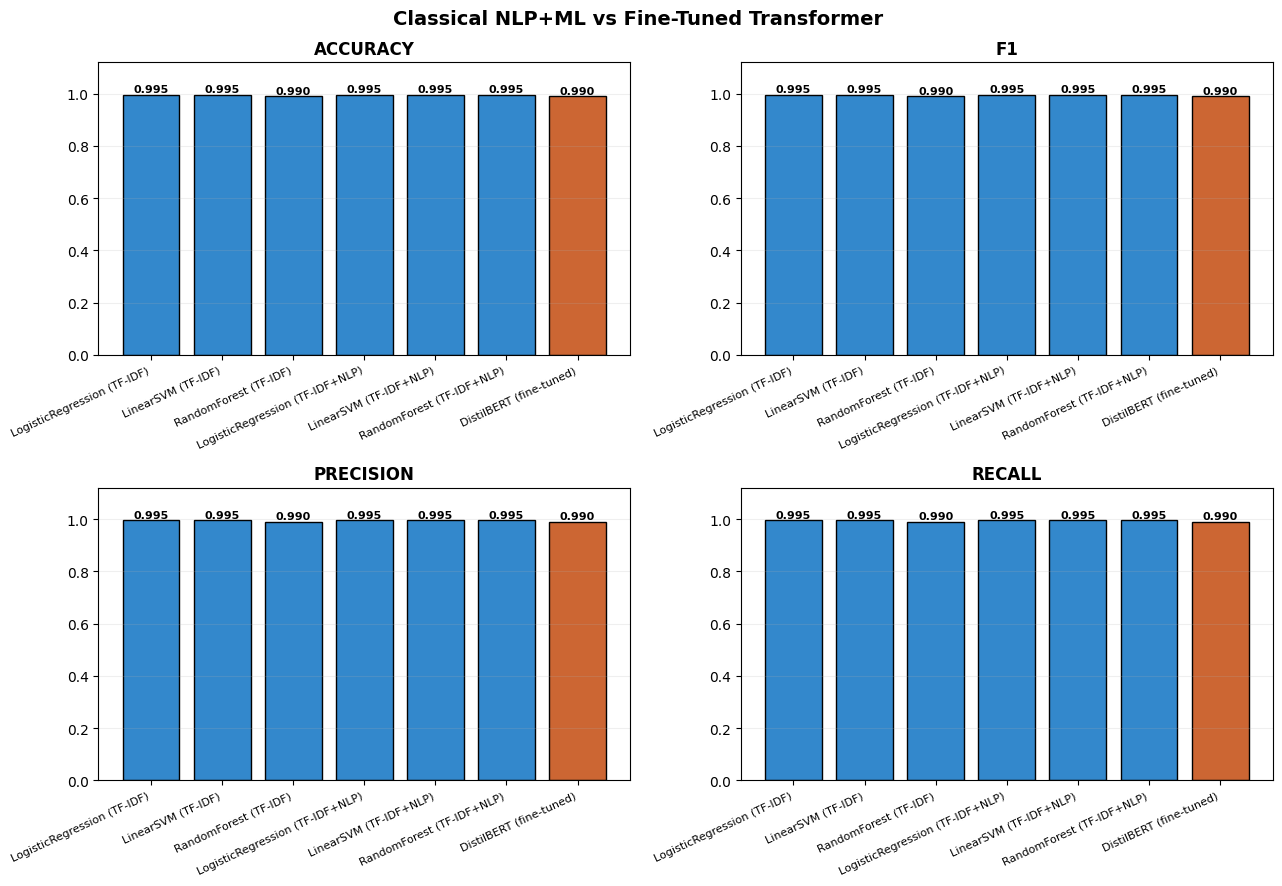

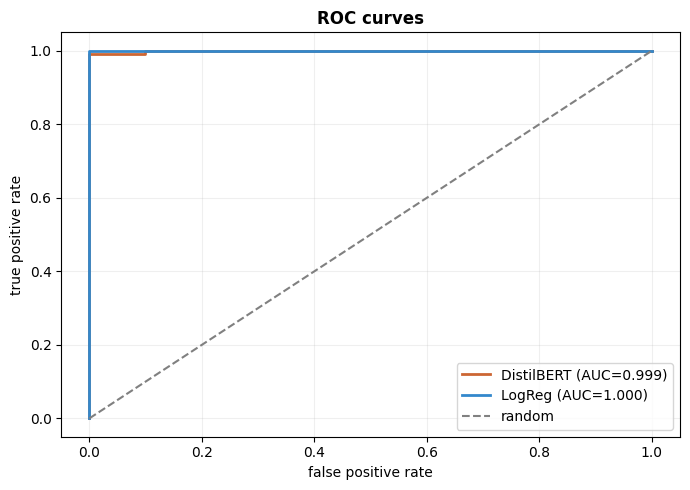


DistilBERT errors on test set: 2/204
  true=safe   pred=attack | Reminder: your password will expire in 14 days. You can update it any time 
  true=safe   pred=attack | Security tip from Finance: we will never ask for your password by email or 

  UNSEEN MESSAGE TEST  (the real generalization benchmark)

> Your colleague mentioned you wanted some swag — can you confirm your home address and tee size?
  expected: safe     (innocuous internal favor)
  LogReg:     attack ✗
  DistilBERT: attack ✗  conf=93%  types: ['phishing', 'credential_theft']

> My grandmother is in the ICU and I need help paying her medical bills. Anything you can give helps.
  expected: attack   (subtle emotional appeal for money)
  LogReg:     attack ✓
  DistilBERT: attack ✓  conf=78%  types: ['scam', 'emotional_manipulation']

> Reset your AWS root password using this calendar link to retain access.
  expected: attack   (credential request via odd channel)
  LogReg:     attack ✓
  DistilBERT: attack ✓  conf=98%  t

In [8]:
# ============================================================================
# PART 7 — EVALUATION, COMPARISON & UNSEEN MESSAGE TEST
# ============================================================================
# Side-by-side comparison of classical NLP+ML vs fine-tuned DistilBERT,
# with all the standard metrics, then a critical generalization test on
# completely unseen messages outside the training distribution.
# ============================================================================

# --- Cell 7.1: results table ---
all_results = {}
for k, r in classical_results.items():
    all_results[k] = {m: r[m] for m in ['accuracy','f1','precision','recall']}
    all_results[k]['type'] = 'Classical'

all_results['DistilBERT (fine-tuned)'] = {
    'accuracy':  accuracy_score(y_test, transformer_preds),
    'f1':        f1_score(y_test, transformer_preds, average='weighted'),
    'precision': precision_score(y_test, transformer_preds, average='weighted'),
    'recall':    recall_score(y_test, transformer_preds, average='weighted'),
    'type':      'Transformer',
}

comp = pd.DataFrame(all_results).T[['type','accuracy','f1','precision','recall']]
print("Model comparison on the held-out test set:"); print(comp.to_string())
comp.to_csv('model_comparison.csv')
print(f"\nBest by F1: {comp['f1'].idxmax()}")

# --- Cell 7.2: bar-chart comparison ---
names = list(all_results.keys())
colors = ['#cc6633' if 'DistilBERT' in n else '#3388cc' for n in names]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, met in zip(axes.flatten(), ['accuracy','f1','precision','recall']):
    vals = [all_results[n][met] for n in names]
    bars = ax.bar(range(len(names)), vals, color=colors, edgecolor='black')
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, v+0.01, f'{v:.3f}',
                ha='center', fontsize=8, fontweight='bold')
    ax.set_title(met.upper(), fontweight='bold')
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=25, ha='right', fontsize=8)
    ax.set_ylim(0, 1.12); ax.grid(axis='y', alpha=0.2)
plt.suptitle('Classical NLP+ML vs Fine-Tuned Transformer', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

# --- Cell 7.3: ROC curves ---
plt.figure(figsize=(7, 5))
# DistilBERT
fpr, tpr, _ = roc_curve(y_test, transformer_probs[:, 1])  # P(safe)
auc_t = roc_auc_score(y_test, transformer_probs[:, 1])
plt.plot(fpr, tpr, color='#cc6633', lw=2, label=f'DistilBERT (AUC={auc_t:.3f})')
# LogReg
lr_decision = lr_model.decision_function(X_test_tfidf)
lr_prob_safe = 1 / (1 + np.exp(-lr_decision))  # sigmoid -> P(safe) since attack=0
fpr2, tpr2, _ = roc_curve(y_test, lr_prob_safe)
auc_l = roc_auc_score(y_test, lr_prob_safe)
plt.plot(fpr2, tpr2, color='#3388cc', lw=2, label=f'LogReg (AUC={auc_l:.3f})')
plt.plot([0, 1], [0, 1], '--', color='gray', label='random')
plt.xlabel('false positive rate'); plt.ylabel('true positive rate')
plt.title('ROC curves', fontweight='bold'); plt.legend(); plt.grid(alpha=0.2)
plt.tight_layout(); plt.show()

# --- Cell 7.4: error analysis on held-out test set ---
tdf = df.iloc[test_idx].copy()
tdf['transformer_pred'] = label_encoder.classes_[transformer_preds]
errors = tdf[tdf['label'] != tdf['transformer_pred']]
print(f"\nDistilBERT errors on test set: {len(errors)}/{len(tdf)}")
for _, row in errors.head(10).iterrows():
    print(f"  true={row['label']:6s} pred={row['transformer_pred']:6s} | {row['text'][:75]}")

# ============================================================================
# --- Cell 7.5: UNSEEN MESSAGE TEST (the most important section) ---
# Brand-new messages that were never in the dataset, including subtle cases.
# This is the real generalization test.
# ============================================================================
UNSEEN_MESSAGES = [
    ("Your colleague mentioned you wanted some swag — can you confirm your home address and tee size?", "safe", "innocuous internal favor"),
    ("My grandmother is in the ICU and I need help paying her medical bills. Anything you can give helps.", "attack", "subtle emotional appeal for money"),
    ("Reset your AWS root password using this calendar link to retain access.", "attack", "credential request via odd channel"),
    ("Could we move the 1:1 to Thursday at 10? I have a conflict at the original time.", "safe", "normal scheduling"),
    ("Your raise is approved! HR needs your full bank routing and account number to update payroll.", "attack", "credential theft posing as good news"),
    ("Hey, the doc you sent earlier won't open for me. Can you re-share it through this signed link?", "attack", "phishing via document re-share"),
    ("Quarterly review meeting tomorrow at 2pm — I'll send the calendar invite shortly.", "safe", "normal business comms"),
    ("URGENT: someone tried to log into your Microsoft account from Russia. Verify immediately at the link.", "attack", "classic phishing"),
    ("Hi, I'm the new finance director. Can you walk me through the wire approval process? Want to make sure I follow correct procedure.", "safe", "legitimate onboarding question"),
    ("Following our call, please update the supplier bank details to the new IBAN. We need to push the next invoice through urgently.", "attack", "BEC / vendor account change scam"),
]

print("\n" + "="*70)
print("  UNSEEN MESSAGE TEST  (the real generalization benchmark)")
print("="*70)

# We also compare classical LogReg vs DistilBERT here
n_correct_lr = 0; n_correct_bert = 0
for text, expected, note in UNSEEN_MESSAGES:
    # Classical
    vec = tfidf.transform([preprocess_text(text)])
    lr_pred = label_encoder.classes_[lr_model.predict(vec)[0]]
    # Transformer
    bert_pred, bert_conf, _ = predict_transformer(text)
    # Multi-label types (if attack predicted)
    types_str = ""
    if bert_pred == "attack":
        _, types = predict_attack_types(text)
        types_str = f"  types: {types}" if types else ""

    lr_ok = "✓" if lr_pred == expected else "✗"
    bert_ok = "✓" if bert_pred == expected else "✗"
    n_correct_lr += (lr_pred == expected)
    n_correct_bert += (bert_pred == expected)

    print(f"\n> {text}")
    print(f"  expected: {expected:6s}   ({note})")
    print(f"  LogReg:     {lr_pred:6s} {lr_ok}")
    print(f"  DistilBERT: {bert_pred:6s} {bert_ok}  conf={bert_conf:.0f}%{types_str}")

print(f"\n{'='*70}")
print(f"Unseen accuracy:   LogReg {n_correct_lr}/{len(UNSEEN_MESSAGES)}  |  "
      f"DistilBERT {n_correct_bert}/{len(UNSEEN_MESSAGES)}")
print("="*70)

cleanup_memory()
print("\nEvaluation complete.")

In [9]:
# ============================================================================
# PART 8 — PROFESSIONAL GRADIO INTERFACE (SaaS Dashboard, bulletproof)
# ============================================================================
# Defensive version: every function from earlier parts is wrapped in try/except
# so we get a clear, readable error message inside the result panel instead
# of a generic "Error" pill that tells you nothing.
#
# If something breaks, the panel shows EXACTLY which function failed and the
# full traceback — so you can fix it in one shot.
# ============================================================================

import gradio as gr
import html as _html
import traceback
import numpy as np

# --- Cell 8.0: HEALTH CHECK -------------------------------------------------
# Verifies every required name from earlier parts exists. Run this once and
# look at the output before clicking "Run analysis".

REQUIRED_NAMES = [
    'predict_transformer',       # Part 4
    'predict_attack_types',      # Part 5
    'get_attention',             # Part 6
    'engineer_features',         # Part 2
    'extract_entities',          # Part 2
    'safe_tokenize',             # Part 2
    'safe_pos',                  # Part 2
    'preprocess_text',           # Part 2
    'tfidf',                     # Part 3
    'classical_results_primary', # Part 3
    'label_encoder',             # Part 2
]

print("=" * 60)
print("HEALTH CHECK — verifying all required names from earlier parts")
print("=" * 60)
_missing = []
for _name in REQUIRED_NAMES:
    if _name in globals():
        print(f"  OK   {_name}")
    else:
        print(f"  MISSING   {_name}")
        _missing.append(_name)
if _missing:
    print("\n*** MISSING NAMES:", _missing)
    print("*** Re-run the parts that define them (see comments above).")
else:
    print("\nAll names present. You can run the Gradio app.")
print("=" * 60)


# --- Cell 8.1: helpers -------------------------------------------------------

def _esc(s):
    return _html.escape(str(s))

TYPE_ICONS = {
    'phishing':                ('fish-hook',         'Phishing'),
    'impersonation':           ('user-shield',       'Impersonation'),
    'urgency':                 ('clock-exclamation', 'Urgency'),
    'credential_theft':        ('key',               'Credential theft'),
    'scam':                    ('moneybag',          'Scam / fraud'),
    'emotional_manipulation':  ('heart-broken',      'Emotional manipulation'),
}

COLOR_RED   = ('#FCEBEB', '#791F1F', '#A32D2D')
COLOR_AMBER = ('#FAEEDA', '#633806', '#854F0B')
COLOR_GREEN = ('#EAF3DE', '#173404', '#3B6D11')

def _risk_palette(score):
    if score > 0.7: return COLOR_RED
    if score > 0.4: return COLOR_AMBER
    return COLOR_GREEN

# Safe wrappers — if a function doesn't exist, fall back to a no-op so the UI
# still renders something instead of crashing.
def _safe_call(fn_name, *args, default=None):
    """Call a function by name from globals(); on any failure return `default`."""
    fn = globals().get(fn_name)
    if fn is None:
        raise NameError(f"Function '{fn_name}' is not defined. "
                        f"Did you run the part that defines it?")
    return fn(*args)


# --- Cell 8.2: card builders -------------------------------------------------

def _verdict_card(label, confidence, summary):
    is_threat = (label == 'attack')
    bg, fg, accent = COLOR_RED if is_threat else COLOR_GREEN
    icon = 'shield-x' if is_threat else 'shield-check'
    headline = 'Threat detected' if is_threat else 'Message appears safe'
    pill_text = 'High risk' if is_threat else 'Low risk'
    bar_pct = max(0, min(100, int(confidence)))
    return f"""
<div style="display:flex; justify-content:space-between; align-items:center; margin-bottom:12px;">
  <div>
    <p style="font-size:14px; font-weight:500; margin:0; color:#1a1a1a;">Analysis result</p>
    <p style="font-size:11px; color:#666; margin:0;">Fine-tuned DistilBERT · multi-label classification</p>
  </div>
  <span style="font-size:11px; padding:4px 12px; border-radius:999px; background:{bg}; color:{fg}; font-weight:500;">{pill_text}</span>
</div>
<div style="background:#fff; border:1px solid #e5e5e5; border-radius:10px; padding:14px; margin-bottom:10px;">
  <div style="display:flex; align-items:start; gap:12px;">
    <div style="width:40px; height:40px; border-radius:50%; background:{bg}; display:flex; align-items:center; justify-content:center; flex-shrink:0;">
      <i class="ti ti-{icon}" style="font-size:22px; color:{accent};"></i>
    </div>
    <div style="flex:1; min-width:0;">
      <div style="font-size:17px; font-weight:500; color:#1a1a1a; margin-bottom:4px;">{headline}</div>
      <p style="font-size:12px; color:#666; margin:0 0 10px; line-height:1.5;">{_esc(summary)}</p>
      <div style="display:flex; align-items:center; gap:10px;">
        <span style="font-size:11px; color:#666; min-width:60px;">Confidence</span>
        <div style="flex:1; height:5px; background:#f1efe8; border-radius:3px; overflow:hidden;">
          <div style="height:100%; width:{bar_pct}%; background:{accent}; border-radius:3px;"></div>
        </div>
        <span style="font-size:13px; font-weight:500; color:#1a1a1a; min-width:38px; text-align:right;">{bar_pct}%</span>
      </div>
    </div>
  </div>
</div>
"""


def _types_card(type_probs):
    if not type_probs: return ""
    items = sorted(type_probs.items(), key=lambda x: -x[1])
    pills, shown = "", 0
    for name, prob in items:
        if prob < 0.15: continue
        bg, fg, _ = _risk_palette(prob)
        icon, label = TYPE_ICONS.get(name, ('alert-triangle', name))
        pct = int(prob * 100)
        pills += (f'<span style="font-size:11px; padding:4px 9px; background:{bg}; color:{fg};'
                  f' border-radius:5px; display:inline-flex; align-items:center; gap:5px;'
                  f' font-weight:500;"><i class="ti ti-{icon}" style="font-size:12px;"></i>'
                  f' {_esc(label)} · {pct}%</span>')
        shown += 1
    if not shown:
        pills = '<span style="font-size:11px; color:#999;">No specific category exceeded threshold.</span>'
    return f"""
<div style="background:#fff; border:1px solid #e5e5e5; border-radius:10px; padding:12px; margin-bottom:10px;">
  <p style="font-size:10px; color:#666; letter-spacing:0.08em; margin:0 0 8px; font-weight:500;">DETECTED ATTACK TYPES</p>
  <div style="display:flex; flex-wrap:wrap; gap:5px;">{pills}</div>
</div>
"""


def _highlight_card(words, scores):
    parts = ""
    for w, s in zip(words, scores):
        sw = _esc(w)
        if s > 0.7:
            parts += (f'<mark style="background:#F09595; color:#501313; padding:1px 5px;'
                      f' border-radius:3px; font-weight:500;">{sw}</mark> ')
        elif s > 0.4:
            parts += (f'<mark style="background:#FAC775; color:#412402; padding:1px 5px;'
                      f' border-radius:3px;">{sw}</mark> ')
        else:
            parts += f'{sw} '
    return f"""
<div style="background:#fff; border:1px solid #e5e5e5; border-radius:10px; padding:12px; margin-bottom:10px;">
  <p style="font-size:10px; color:#666; letter-spacing:0.08em; margin:0 0 8px; font-weight:500;">WHY WE FLAGGED THIS</p>
  <div style="font-size:12px; line-height:2; color:#1a1a1a;">{parts}</div>
  <div style="display:flex; gap:12px; margin-top:8px; font-size:10px; color:#666;">
    <span style="display:inline-flex; align-items:center; gap:5px;">
      <span style="width:8px; height:8px; background:#F09595; border-radius:2px;"></span> high attention
    </span>
    <span style="display:inline-flex; align-items:center; gap:5px;">
      <span style="width:8px; height:8px; background:#FAC775; border-radius:2px;"></span> medium attention
    </span>
  </div>
</div>
"""


def _nlp_feature_card(feats, pos_counts, entities):
    n_verb, n_noun, n_adj = pos_counts
    ent_str = ", ".join(sorted(entities.keys())) if entities else "none"
    urg_color = COLOR_RED[2] if feats['urgency_score'] >= 2 else (COLOR_AMBER[2] if feats['urgency_score']>=1 else '#1a1a1a')
    act_color = COLOR_RED[2] if feats['action_score']  >= 2 else (COLOR_AMBER[2] if feats['action_score'] >=1 else '#1a1a1a')
    return f"""
<div style="background:#fff; border:1px solid #e5e5e5; border-radius:10px; padding:12px; margin-bottom:10px;">
  <p style="font-size:10px; color:#666; letter-spacing:0.08em; margin:0 0 8px; font-weight:500;">NLP FEATURE ANALYSIS</p>
  <div style="display:grid; grid-template-columns:1fr 1fr; gap:10px; font-size:11px;">
    <div style="display:flex; flex-direction:column; gap:4px;">
      <div><span style="color:#666;">Tokens:</span> <span style="font-weight:500;">{feats['word_len']}</span></div>
      <div><span style="color:#666;">Urgency score:</span> <span style="font-weight:500; color:{urg_color};">{feats['urgency_score']}</span></div>
      <div><span style="color:#666;">Action verbs:</span> <span style="font-weight:500; color:{act_color};">{feats['action_score']}</span></div>
      <div><span style="color:#666;">Uppercase words:</span> <span style="font-weight:500;">{feats['uppercase_words']}</span></div>
    </div>
    <div style="display:flex; flex-direction:column; gap:4px;">
      <div><span style="color:#666;">POS — verbs:</span> <span style="font-weight:500;">{n_verb}</span></div>
      <div><span style="color:#666;">POS — nouns:</span> <span style="font-weight:500;">{n_noun}</span></div>
      <div><span style="color:#666;">POS — adjectives:</span> <span style="font-weight:500;">{n_adj}</span></div>
      <div><span style="color:#666;">Entities found:</span> <span style="font-weight:500;">{_esc(ent_str)}</span></div>
    </div>
  </div>
</div>
"""


def _nlp_charts_card(feats, pos_counts, entities):
    n_verb, n_noun, n_adj = pos_counts
    def _bar(label, value, max_val, color):
        pct = int(min(100, (value / max_val) * 100)) if max_val else 0
        return f"""
<div style="display:flex; align-items:center; gap:8px; margin-bottom:5px;">
  <span style="font-size:10px; color:#666; min-width:90px;">{label}</span>
  <div style="flex:1; height:6px; background:#f1efe8; border-radius:3px; overflow:hidden;">
    <div style="height:100%; width:{pct}%; background:{color}; border-radius:3px;"></div>
  </div>
  <span style="font-size:11px; font-weight:500; min-width:20px; text-align:right;">{value}</span>
</div>
"""
    linguistic = (_bar("Urgency", feats['urgency_score'], 5, COLOR_RED[2]) +
                  _bar("Action", feats['action_score'], 5, COLOR_AMBER[2]) +
                  _bar("Uppercase", feats['uppercase_words'], 5, COLOR_AMBER[2]) +
                  _bar("Has money", feats['has_money'], 1, COLOR_RED[2]) +
                  _bar("Link cue", feats['has_link_cue'], 1, COLOR_AMBER[2]))
    max_pos = max(n_verb, n_noun, n_adj, 1)
    pos_b = (_bar("Verbs", n_verb, max_pos, COLOR_RED[2]) +
             _bar("Nouns", n_noun, max_pos, '#3388cc') +
             _bar("Adjectives", n_adj, max_pos, COLOR_AMBER[2]))
    if entities:
        max_ent = max((len(v) for v in entities.values()), default=1)
        ent_colors = {'ORG': COLOR_RED[2], 'MONEY': COLOR_AMBER[2], 'TIME': COLOR_RED[2], 'LINK': COLOR_AMBER[2]}
        ent_b = "".join(_bar(et, len(v), max_ent, ent_colors.get(et, '#3388cc')) for et, v in entities.items())
    else:
        ent_b = '<p style="font-size:11px; color:#999; margin:0;">No entities detected.</p>'
    return f"""
<div style="background:#fff; border:1px solid #e5e5e5; border-radius:10px; padding:12px; margin-bottom:10px;">
  <p style="font-size:10px; color:#666; letter-spacing:0.08em; margin:0 0 10px; font-weight:500;">NLP FEATURE CHARTS</p>
  <div style="margin-bottom:12px;">
    <p style="font-size:10px; color:#888; margin:0 0 6px; font-weight:500;">Linguistic signals</p>
    {linguistic}
  </div>
  <div style="margin-bottom:12px;">
    <p style="font-size:10px; color:#888; margin:0 0 6px; font-weight:500;">Part-of-speech distribution</p>
    {pos_b}
  </div>
  <div>
    <p style="font-size:10px; color:#888; margin:0 0 6px; font-weight:500;">Named entities</p>
    {ent_b}
  </div>
</div>
"""


def _top_words_card(words, scores):
    if len(words) == 0: return ""
    pairs = sorted(zip(words, scores), key=lambda x: -x[1])[:8]
    rows = ""
    for w, s in pairs:
        bg, fg, accent = _risk_palette(s)
        level = "HIGH" if s > 0.7 else ("MED" if s > 0.4 else "LOW")
        bar_pct = int(s * 100)
        rows += f"""
<div style="display:flex; align-items:center; gap:8px; margin-bottom:5px;">
  <span style="font-size:10px; padding:2px 6px; background:{bg}; color:{fg};
               border-radius:3px; font-weight:500; min-width:38px; text-align:center;">{level}</span>
  <span style="font-size:11px; font-weight:500; color:#1a1a1a; min-width:90px; max-width:90px; overflow:hidden; text-overflow:ellipsis; white-space:nowrap;">{_esc(w)}</span>
  <div style="flex:1; height:5px; background:#f1efe8; border-radius:3px; overflow:hidden;">
    <div style="height:100%; width:{bar_pct}%; background:{accent}; border-radius:3px;"></div>
  </div>
  <span style="font-size:11px; color:#666; min-width:34px; text-align:right;">{s:.2f}</span>
</div>
"""
    return f"""
<div style="background:#fff; border:1px solid #e5e5e5; border-radius:10px; padding:12px; margin-bottom:10px;">
  <p style="font-size:10px; color:#666; letter-spacing:0.08em; margin:0 0 8px; font-weight:500;">TOP SUSPICIOUS WORDS (BY ATTENTION)</p>
  {rows}
</div>
"""


def _confidence_comparison_card(text, transformer_label, transformer_conf):
    try:
        vec = tfidf.transform([preprocess_text(text)])
    except Exception as e:
        return f'<div style="background:#fff; border:1px solid #e5e5e5; border-radius:10px; padding:12px; color:#999; font-size:11px;">Confidence comparison unavailable: {_esc(str(e))}</div>'

    rows = ""
    bg, fg, accent = _risk_palette(0.9 if transformer_label == 'attack' else 0.1)
    bar_pct = int(transformer_conf)
    rows += f"""
<div style="margin-bottom:8px;">
  <div style="display:flex; justify-content:space-between; align-items:center; margin-bottom:3px;">
    <span style="font-size:11px; color:#1a1a1a; font-weight:500;">DistilBERT</span>
    <span style="font-size:11px; font-weight:500; color:{accent};">{transformer_label.upper()} · {bar_pct}%</span>
  </div>
  <div style="height:5px; background:#f1efe8; border-radius:3px; overflow:hidden;">
    <div style="height:100%; width:{bar_pct}%; background:{accent}; border-radius:3px;"></div>
  </div>
</div>
"""
    for name, r in classical_results_primary.items():
        try:
            model = r['model']
            pred = label_encoder.classes_[model.predict(vec)[0]]
            if hasattr(model, 'predict_proba'):
                probs = model.predict_proba(vec)[0]; conf = float(np.max(probs))
            elif hasattr(model, 'decision_function'):
                score = float(model.decision_function(vec)[0])
                conf = 1.0 / (1.0 + np.exp(-abs(score)))
            else:
                conf = 1.0
        except Exception:
            continue
        bg, fg, accent = _risk_palette(0.9 if pred == 'attack' else 0.1)
        bar_pct = int(conf * 100)
        rows += f"""
<div style="margin-bottom:8px;">
  <div style="display:flex; justify-content:space-between; align-items:center; margin-bottom:3px;">
    <span style="font-size:11px; color:#666;">{_esc(name)}</span>
    <span style="font-size:11px; font-weight:500; color:{accent};">{pred.upper()} · {bar_pct}%</span>
  </div>
  <div style="height:5px; background:#f1efe8; border-radius:3px; overflow:hidden;">
    <div style="height:100%; width:{bar_pct}%; background:{accent}; border-radius:3px;"></div>
  </div>
</div>
"""
    return f"""
<div style="background:#fff; border:1px solid #e5e5e5; border-radius:10px; padding:12px; margin-bottom:10px;">
  <p style="font-size:10px; color:#666; letter-spacing:0.08em; margin:0 0 10px; font-weight:500;">MODEL CONFIDENCE COMPARISON</p>
  {rows}
</div>
"""


def _consensus_card(text, transformer_label, transformer_conf):
    try:
        vec = tfidf.transform([preprocess_text(text)])
    except Exception:
        return ""
    rows = ""
    bg, fg, _ = _risk_palette(0.9 if transformer_label == 'attack' else 0.1)
    rows += (f'<div style="display:flex; justify-content:space-between; padding:5px 0; border-bottom:1px solid #f1efe8;">'
             f'<span style="color:#1a1a1a; font-weight:500;">DistilBERT (fine-tuned)</span>'
             f'<span style="font-size:10px; padding:2px 8px; background:{bg}; color:{fg}; border-radius:99px; font-weight:500;">{transformer_label.upper()} · {int(transformer_conf)}%</span>'
             f'</div>')
    for name, r in classical_results_primary.items():
        try:
            pred = label_encoder.classes_[r['model'].predict(vec)[0]]
        except Exception:
            continue
        bg, fg, _ = _risk_palette(0.9 if pred == 'attack' else 0.1)
        rows += (f'<div style="display:flex; justify-content:space-between; padding:5px 0; border-bottom:1px solid #f1efe8;">'
                 f'<span style="color:#666;">{_esc(name)}</span>'
                 f'<span style="font-size:10px; padding:2px 8px; background:{bg}; color:{fg}; border-radius:99px; font-weight:500;">{pred.upper()}</span>'
                 f'</div>')
    return f"""
<div style="background:#fff; border:1px solid #e5e5e5; border-radius:10px; padding:12px;">
  <p style="font-size:10px; color:#666; letter-spacing:0.08em; margin:0 0 4px; font-weight:500;">MODEL CONSENSUS</p>
  <div style="font-size:11px;">{rows}</div>
</div>
"""


def _error_card(stage, exc):
    """Shown when something blows up — gives the user a useful diagnostic."""
    tb = _html.escape(traceback.format_exc())
    return f"""
<div style="background:#FCEBEB; border:1px solid #f3c5c5; border-radius:10px; padding:16px; margin-bottom:10px;">
  <div style="display:flex; align-items:start; gap:10px;">
    <div style="width:32px; height:32px; border-radius:50%; background:#A32D2D; display:flex; align-items:center; justify-content:center; flex-shrink:0;">
      <i class="ti ti-alert-triangle" style="font-size:18px; color:#fff;"></i>
    </div>
    <div style="flex:1; min-width:0;">
      <div style="font-size:14px; font-weight:600; color:#791F1F;">Analysis failed at: {_esc(stage)}</div>
      <p style="font-size:12px; color:#791F1F; margin:4px 0 8px;">{_esc(type(exc).__name__)}: {_esc(str(exc))}</p>
      <details style="font-size:11px; color:#666;">
        <summary style="cursor:pointer; user-select:none;">Show full traceback</summary>
        <pre style="background:#fff; border:1px solid #e5e5e5; border-radius:6px; padding:8px; margin-top:6px; font-size:10px; overflow:auto; max-height:240px; white-space:pre-wrap;">{tb}</pre>
      </details>
      <p style="font-size:11px; color:#791F1F; margin-top:8px;">
        Tip: re-run the part that defines this function, then click <b>Run analysis</b> again.
      </p>
    </div>
  </div>
</div>
"""


# --- Cell 8.3: main analysis (every step in its own try/except) -------------

def analyze_message(text):
    if not text or not text.strip():
        return """
<div style="padding:80px 20px; text-align:center; color:#999; font-family:sans-serif;
            background:#fff; border:1px solid #e5e5e5; border-radius:10px;">
  <i class="ti ti-paste" style="font-size:32px; opacity:0.4;"></i>
  <p style="margin-top:10px; font-size:13px;">Paste a message on the left and click <b>Run analysis</b>.</p>
</div>
"""

    # Stage 1: binary verdict
    try:
        label, conf, _ = _safe_call('predict_transformer', text)
    except Exception as e:
        return _error_card("binary verdict (predict_transformer)", e)

    # Stage 2: NLP features (each independently — partial failure shouldn't kill the page)
    try:
        feats = _safe_call('engineer_features', text)
    except Exception as e:
        return _error_card("feature engineering (engineer_features)", e)

    try:
        entities = _safe_call('extract_entities', text)
    except Exception:
        entities = {}

    try:
        toks = [w.lower() for w in _safe_call('safe_tokenize', text) if w.isalpha()]
        pos_tags = _safe_call('safe_pos', toks)
        n_verb = sum(1 for _, t in pos_tags if t.startswith('VB'))
        n_noun = sum(1 for _, t in pos_tags if t.startswith('NN'))
        n_adj  = sum(1 for _, t in pos_tags if t.startswith('JJ'))
        pos_counts = (n_verb, n_noun, n_adj)
    except Exception:
        pos_counts = (0, 0, 0)

    # Stage 3: attack types (only meaningful if attack)
    if label == 'attack':
        try:
            type_probs, detected = _safe_call('predict_attack_types', text)
        except Exception as e:
            return _error_card("attack typing (predict_attack_types)", e)
        if detected:
            type_names_lc = [TYPE_ICONS[d][1].lower() for d in detected]
            summary = "Signs of " + ", ".join(type_names_lc) + "."
        else:
            summary = "Flagged as suspicious, though no single category dominates — likely subtle manipulation."
    else:
        type_probs = {}
        summary = "No social engineering patterns detected. Stay cautious with unexpected requests."

    # Stage 4: attention
    try:
        words, scores = _safe_call('get_attention', text)
    except Exception as e:
        return _error_card("attention extraction (get_attention)", e)

    # Build the page
    try:
        parts = [
            _verdict_card(label, conf, summary),
            _types_card(type_probs) if label == 'attack' else "",
            _highlight_card(words, scores),
            _nlp_feature_card(feats, pos_counts, entities),
            _nlp_charts_card(feats, pos_counts, entities),
            _top_words_card(words, scores),
            _confidence_comparison_card(text, label, conf),
            _consensus_card(text, label, conf),
        ]
        return "\n".join(parts)
    except Exception as e:
        return _error_card("rendering result cards", e)


# --- Cell 8.4: CSS ----------------------------------------------------------

CUSTOM_CSS = """
@import url('https://cdn.jsdelivr.net/npm/@tabler/icons-webfont@2.47.0/tabler-icons.min.css');

.gradio-container {
    font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', sans-serif !important;
    max-width: 1100px !important;
    background: #fafaf9 !important;
}
footer { visibility: hidden !important; }

.app-header {
    background: #FCEBEB;
    border: 1px solid #f3c5c5;
    border-radius: 12px;
    padding: 22px 24px;
    margin: 16px 4px 22px;
    display: flex;
    align-items: center;
    gap: 16px;
}
.app-header .icon-wrap {
    width: 52px; height: 52px; border-radius: 50%; background: #A32D2D;
    display: flex; align-items: center; justify-content: center; flex-shrink: 0;
}
.app-header .icon-wrap i { font-size: 26px; color: #fff; }
.app-header h1 {
    font-size: 22px !important; font-weight: 600 !important;
    color: #791F1F !important; margin: 0 0 4px 0 !important; letter-spacing: -0.01em;
}
.app-header p {
    font-size: 12px !important; color: #A32D2D !important; margin: 0 !important; font-weight: 500;
}

.input-card { background: #fff; border: 1px solid #e5e5e5; border-radius: 10px; padding: 14px; }
.input-card label span {
    font-size: 10px !important; color: #666 !important; letter-spacing: 0.08em !important;
    text-transform: uppercase !important; font-weight: 500 !important;
}

textarea {
    font-family: -apple-system, sans-serif !important;
    font-size: 13px !important; line-height: 1.5 !important;
    border: 1px solid #e5e5e5 !important; border-radius: 6px !important;
    background: #fafaf9 !important; padding: 10px !important; color: #1a1a1a !important;
}
textarea:focus {
    border-color: #A32D2D !important;
    box-shadow: 0 0 0 3px rgba(163,45,45,0.08) !important; outline: none !important;
}

button.primary {
    background: #A32D2D !important; color: #fff !important; border: none !important;
    border-radius: 6px !important; font-size: 13px !important; font-weight: 500 !important;
    padding: 10px 18px !important; cursor: pointer !important; transition: background 0.15s !important;
}
button.primary:hover { background: #791F1F !important; }

.examples-holder { background: transparent !important; border: none !important; }
.examples-holder th { display: none !important; }
.examples-holder td {
    font-size: 11px !important; color: #666 !important;
    border: 1px solid #e5e5e5 !important; border-radius: 6px !important;
    padding: 7px 10px !important; background: #fff !important;
    cursor: pointer !important; transition: all 0.15s !important;
}
.examples-holder tr:hover td {
    color: #A32D2D !important; border-color: #f3c5c5 !important; background: #FCEBEB !important;
}
"""


# --- Cell 8.5: build interface ----------------------------------------------

with gr.Blocks(css=CUSTOM_CSS, theme=gr.themes.Base()) as interface:

    gr.HTML("""
    <div class="app-header">
      <div class="icon-wrap"><i class="ti ti-shield-lock"></i></div>
      <div>
        <h1>Social engineering detector</h1>
        <p>Fine-tuned DistilBERT · classical NLP baselines · multi-label attack typing</p>
      </div>
    </div>
    """)

    with gr.Row():
        with gr.Column(scale=4):
            with gr.Group(elem_classes="input-card"):
                user_input = gr.Textbox(
                    lines=8,
                    placeholder="Paste a suspicious email, SMS, Slack message, or any text...",
                    label="Message to analyze",
                    show_label=True,
                )
                analyze_btn = gr.Button("Run analysis", variant="primary")

            gr.HTML('<p style="font-size:10px; color:#666; letter-spacing:0.08em; '
                    'text-transform:uppercase; font-weight:500; margin:14px 0 8px;">Examples</p>')

            gr.Examples(
                examples=[
                    ["URGENT: Your bank account has been locked. Verify your identity immediately."],
                    ["CEO Request: Transfer the payment immediately. Keep this confidential."],
                    ["Hi, this is John from IT. We need your login credentials for the migration."],
                    ["My grandmother is in the ICU and I need help paying her bills."],
                    ["You won a free iPhone! Click now to claim your reward before it expires."],
                    ["Hey team, the weekly standup is at 3 PM. See you there."],
                    ["Your dental appointment is confirmed for Tuesday at 10 AM."],
                    ["Following our call, please update the supplier bank details to the new IBAN."],
                ],
                inputs=user_input,
            )

        with gr.Column(scale=5):
            result_html = gr.HTML(value="""
<div style="padding:80px 20px; text-align:center; color:#999; font-family:sans-serif;
            background:#fff; border:1px solid #e5e5e5; border-radius:10px;">
  <i class="ti ti-paste" style="font-size:32px; opacity:0.4;"></i>
  <p style="margin-top:10px; font-size:13px;">Paste a message on the left and click <b>Run analysis</b>.</p>
</div>
""")

    analyze_btn.click(analyze_message, inputs=user_input, outputs=result_html)
    user_input.submit(analyze_message, inputs=user_input, outputs=result_html)

    gr.HTML("""
    <div style="margin-top:24px; padding:14px 0; border-top:1px solid #e5e5e5; text-align:center;">
      <p style="font-size:10px; color:#999; margin:0;">
        Python · NLTK · scikit-learn · PyTorch · Hugging Face · DistilBERT · Gradio
      </p>
    </div>
    """)


# --- Cell 8.6: launch -------------------------------------------------------
interface.launch(share=True, debug=False)

HEALTH CHECK — verifying all required names from earlier parts
  OK   predict_transformer
  OK   predict_attack_types
  OK   get_attention
  OK   engineer_features
  OK   extract_entities
  OK   safe_tokenize
  OK   safe_pos
  OK   preprocess_text
  OK   tfidf
  OK   classical_results_primary
  OK   label_encoder

All names present. You can run the Gradio app.
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f302360379aa924c8e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
